In [29]:
import os
from pathlib import Path
import shutil
import tempfile

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from dotenv import load_dotenv, find_dotenv

In [14]:
# Load environment (if present) and connect to DuckDB read-only.
# On Windows, DuckDB may fail if another process holds an exclusive lock.
dotenv_path = find_dotenv(usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path, override=False)
else:
    # Fallback: typical repo layout where notebook is in ./signals and .env is at repo root
    load_dotenv(Path('..') / '.env', override=False)

# Resolve repo root (works whether cwd is repo root or ./signals)
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name.lower() == 'signals' else cwd

default_db_path = repo_root / 'data' / 'research.duckdb'
DB_PATH = Path(os.getenv('DUCKDB_PATH', str(default_db_path))).expanduser()
DB_PATH = (repo_root / DB_PATH).resolve() if not DB_PATH.is_absolute() else DB_PATH.resolve()

def connect_duckdb_readonly(db_path: Path):
    try:
        return duckdb.connect(str(db_path), read_only=True)
    except Exception as e:
        msg = str(e).lower()
        locked = ('being used by another process' in msg) or ('used by another process' in msg)
        if locked:
            # Fallback: try copying the DB to a temp path and opening that copy read-only.
            tmp_dir = Path(tempfile.gettempdir()) / 'margincallcapital'
            tmp_dir.mkdir(parents=True, exist_ok=True)
            db_copy_path = tmp_dir / f'{db_path.stem}_copy{db_path.suffix}'
            try:
                shutil.copy2(db_path, db_copy_path)
                print(f'DB appears locked; using temp copy: {db_copy_path}')
                return duckdb.connect(str(db_copy_path), read_only=True)
            except Exception as copy_err:
                raise RuntimeError(
                    f"DuckDB DB is locked and couldn't be copied.\n\nOriginal error: {e}\nCopy error: {copy_err}\n\n"
                    "Close any DuckDB viewer/extension or other process connected to the DB, then retry."
                )
        raise

con = connect_duckdb_readonly(DB_PATH)
print(f'Connected to {DB_PATH}')

Connected to C:\Users\User\Desktop\MarginCallCapital\margincallcapital\data\research.duckdb


# Connect to DB

In [16]:
# List tables
tables = con.sql("SHOW TABLES").df()
tables

# Load close data for multiple symbols at the base interval, then we'll resample to other timeframes.
base_interval = "1h"

symbols_df = con.execute(
    """
    SELECT DISTINCT symbol
    FROM ohlcv
    WHERE interval = ? AND symbol NOT LIKE '%USDT%'
    ORDER BY symbol
    """,
    [base_interval],
).df()

symbols = symbols_df["symbol"].astype(str).tolist()
print(f"Found {len(symbols)} symbols at interval={base_interval}")

# For quick iteration, start with a smaller universe (adjust as you like).
symbols = symbols[:25]
print("Using symbols:", symbols)

def load_close_matrix(con, symbols, interval: str) -> pd.DataFrame:
    if not symbols:
        raise ValueError("No symbols provided")
    placeholders = ", ".join(["?"] * len(symbols))
    sql = f"""
    SELECT ts, symbol, close
    FROM ohlcv
    WHERE interval = ? AND symbol IN ({placeholders})
    ORDER BY ts
    """
    df_long = con.execute(sql, [interval, *symbols]).df()
    df_long["ts"] = pd.to_datetime(df_long["ts"])
    close_wide = (
        df_long.pivot(index="ts", columns="symbol", values="close")
        .sort_index()
        .astype(float)
    )
    return close_wide

close_1h = load_close_matrix(con, symbols, base_interval)
close_1h.tail()

Found 5 symbols at interval=1h
Using symbols: ['BNB-USD', 'BTC-USD', 'ETH-USD', 'SOL-USD', 'XRP-USD']


symbol,BNB-USD,BTC-USD,ETH-USD,SOL-USD,XRP-USD
ts,,,,,
2026-03-18 18:00:00+08:00,672.44,73946.35,2312.83,93.86,1.5111
2026-03-18 19:00:00+08:00,662.89,72952.85,2269.34,92.00,1.4895
2026-03-18 20:00:00+08:00,657.74,72361.24,2237.49,90.43,1.4640
2026-03-18 21:00:00+08:00,657.49,72133.49,2235.68,90.32,1.4664
2026-03-18 22:00:00+08:00,650.61,71520.62,2204.44,89.29,1.4500


## Skeleton for coin momentum

## Momentum over time

Compute rolling-window momentum from the combined cross-sectional score and visualize:
- Market-wide average momentum (spot + rolling windows).
- Per-coin rolling momentum trajectories for leaders/laggards.

Windows are expressed in 1h bars: `24h = 24`, `3d = 72`, `7d = 168`.

In [22]:
# -------------------------------------------------------------------
# 1. CORE SIGNAL GENERATION (Fully Vectorized)
# -------------------------------------------------------------------

def calculate_matrix_signal(close_df: pd.DataFrame, fast_span: int, slow_span: int, vol_span: int) -> pd.DataFrame:
    """
    Calculates the momentum z-score for an entire price matrix simultaneously.
    """
    # Calculate EMAs across all columns at once (no loops needed)
    ma_s = close_df.ewm(span=fast_span, adjust=False).mean()
    ma_l = close_df.ewm(span=slow_span, adjust=False).mean()
    
    spread = ma_s - ma_l
    
    # Volatility normalization (parameterized so it fits the timeframe)
    spread_std = spread.ewm(span=vol_span, adjust=False).std()
    
    # Calculate Z-score (safeguard against division by zero)
    z_score = spread / spread_std.replace(0.0, np.nan)
    
    # CRITICAL: Shift by 1 bar in the native timeframe to prevent lookahead bias
    return z_score.shift(1)

def cross_sectional_rank_to_unit(z_score_df: pd.DataFrame) -> pd.DataFrame:
    """
    Row-wise percentile rank mapped to [-1, 1].
    """
    pct = z_score_df.rank(axis=1, pct=True, method='average')
    return pct * 2 - 1

# -------------------------------------------------------------------
# 2. TIMEFRAME CONFIGURATION
# -------------------------------------------------------------------
# Added 'vol' to parameterize the volatility normalization window for each timeframe.

TIMEFRAMES = {
    '1h':  {'rule': '1h', 'fast': 24, 'slow': 72, 'vol': 260},  # ~10 days of vol on 1h
    '4h':  {'rule': '4h', 'fast': 18, 'slow': 54, 'vol': 180},  # ~30 days of vol on 4h
    '1d':  {'rule': '1D', 'fast': 20, 'slow': 60, 'vol': 90},   # 90 days of vol on daily
}

# -------------------------------------------------------------------
# 3. EXECUTION PIPELINE
# -------------------------------------------------------------------

# Assuming `close_1h` is your base DataFrame of hourly closes
signals_by_tf = {}
xsec_momentum_by_tf = {}

for name, cfg in TIMEFRAMES.items():
    # 1. Resample to the target timeframe
    if cfg['rule'] == '1h':
        close_tf = close_1h 
    else:
        # label='right', closed='right' ensures the daily bar timestamp represents the end of the day
        close_tf = close_1h.resample(cfg['rule'], label='right', closed='right').last()
    
    # 2. Compute the vectorized z-score signal (this handles the shift(1) internally)
    sig_tf = calculate_matrix_signal(close_tf, cfg['fast'], cfg['slow'], cfg['vol'])
    
    # 3. Rank cross-sectionally
    xsec_tf = cross_sectional_rank_to_unit(sig_tf)
    
    # 4. Project back to the hourly grid (forward fill)
    # The signal generated at the end of Monday is now available at 00:00 Tuesday.
    xsec_tf_aligned = xsec_tf.reindex(close_1h.index, method='ffill')
    
    signals_by_tf[name] = sig_tf
    xsec_momentum_by_tf[name] = xsec_tf_aligned

# -------------------------------------------------------------------
# 4. AGGREGATION
# -------------------------------------------------------------------

# Combine timeframes into a single cross-coin momentum score.
# Using pd.concat to group by index natively handles mean calculations while ignoring NaNs.
combined_xsec = pd.concat(xsec_momentum_by_tf.values()).groupby(level=0).mean()

# Example outputs
print('Signal matrix (1h) tail:')
print(signals_by_tf['1h'].tail())

print('\nCombined cross-coin momentum tail:')
print(combined_xsec.tail())

# Latest ranking snapshot
latest = combined_xsec.dropna(how='all').iloc[-1].sort_values(ascending=False)
print('\nLatest Top 10 Momentum Coins:')
print(latest.head(10))

Signal matrix (1h) tail:
symbol                      BNB-USD   BTC-USD   ETH-USD   SOL-USD   XRP-USD
ts                                                                         
2026-03-18 18:00:00+08:00  0.458932  1.001275  1.487200  1.113471  1.432848
2026-03-18 19:00:00+08:00  0.445993  0.960739  1.433867  1.063680  1.363715
2026-03-18 20:00:00+08:00  0.317283  0.833942  1.314999  0.930292  1.237046
2026-03-18 21:00:00+08:00  0.138040  0.665070  1.155431  0.734855  1.047168
2026-03-18 22:00:00+08:00 -0.026220  0.490994  1.006786  0.552010  0.881309

Combined cross-coin momentum tail:
symbol                      BNB-USD  BTC-USD   ETH-USD   SOL-USD  XRP-USD
ts                                                                       
2026-03-18 18:00:00+08:00 -0.066667      0.2  0.733333 -0.066667      0.2
2026-03-18 19:00:00+08:00 -0.066667      0.2  0.733333 -0.066667      0.2
2026-03-18 20:00:00+08:00 -0.066667      0.2  0.733333 -0.066667      0.2
2026-03-18 21:00:00+08:00 -0.066667  

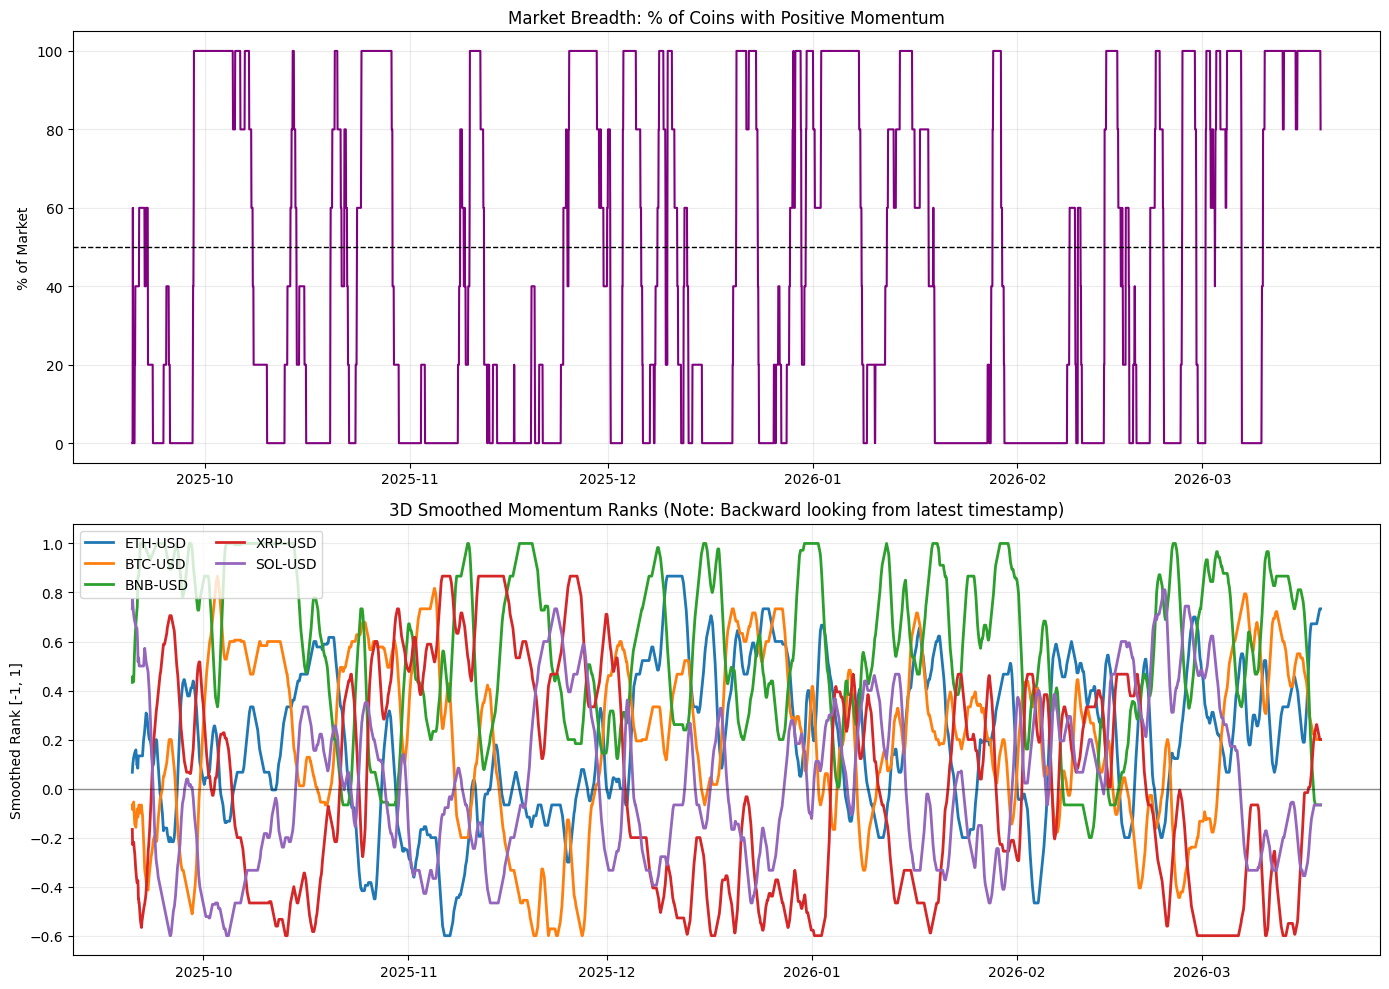

In [ ]:
# -------------------------------------------------------------------
# 1. ROLLING SMOOTHING (For churn reduction)
# -------------------------------------------------------------------
if 'combined_xsec' not in globals():
    raise RuntimeError('Run the previous momentum cell first.')

rolling_windows = {'1d': 24, '3d': 72, '7d': 168}
rolling_scores = {}

for label, window in rolling_windows.items():
    min_periods = max(3, window // 4)
    # Smoothing the ranks to create a "slowed down" allocation signal
    rolling_scores[label] = combined_xsec.rolling(window=window, min_periods=min_periods).mean()

# -------------------------------------------------------------------
# 2. MARKET BREADTH (Fixing the Zero-Mean Trap)
# -------------------------------------------------------------------
# Instead of averaging ranks, we calculate what % of the market is in an "uptrend"
# We'll use the 1h signal from the previous step (before it was ranked)
if 'signals_by_tf' in globals() and '1h' in signals_by_tf:
    raw_1h_zscore = signals_by_tf['1h']
    # % of coins with a positive Z-score (bullish momentum)
    market_breadth = (raw_1h_zscore > 0).mean(axis=1) * 100 
else:
    # Fallback if raw signals aren't available: % of coins above 0 in the rank 
    # (less accurate, but works as a proxy)
    market_breadth = (combined_xsec > 0).mean(axis=1) * 100

# -------------------------------------------------------------------
# 3. SNAPSHOT & VISUALIZATION
# -------------------------------------------------------------------
latest_ts = combined_xsec.dropna(how='all').index[-1]
latest_snapshot = pd.DataFrame({'spot': combined_xsec.loc[latest_ts]})
for label, df in rolling_scores.items():
    latest_snapshot[label] = df.loc[latest_ts]

# Sort by the 3d smoothed rank for a more stable top/bottom selection
rank_col = '3d' if latest_snapshot['3d'].notna().any() else 'spot'
latest_snapshot = latest_snapshot.sort_values(rank_col, ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# --- Plot 1: Market Breadth ---
axes[0].plot(market_breadth.index, market_breadth, color='purple', linewidth=1.5)
axes[0].axhline(50.0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Market Breadth: % of Coins with Positive Momentum')
axes[0].set_ylabel('% of Market')
axes[0].grid(alpha=0.25)

# --- Plot 2: Top vs Bottom Trajectories (Warning: Hindsight Bias applied!) ---
coin_plot_df = rolling_scores['1d']
top_symbols = latest_snapshot.head(5).index.tolist()

for sym in top_symbols:
    if sym in coin_plot_df.columns:
        axes[1].plot(coin_plot_df.index, coin_plot_df[sym], linewidth=2, label=f'{sym}')


axes[1].axhline(0.0, color='black', linewidth=1, alpha=0.4)
axes[1].set_title('3D Smoothed Momentum Ranks (Note: Backward looking from latest timestamp)')
axes[1].set_ylabel('Smoothed Rank [-1, 1]')
axes[1].legend(loc='upper left', ncol=2)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

--- IC Summary Statistics ---
Mean IC:      -0.0031
IC Std Dev:   0.5270
IC IR (Risk): -0.0059  (> 0.5 is good, > 1.0 is exceptional)
Hit Rate:     47.14% (> 50% is required for edge)


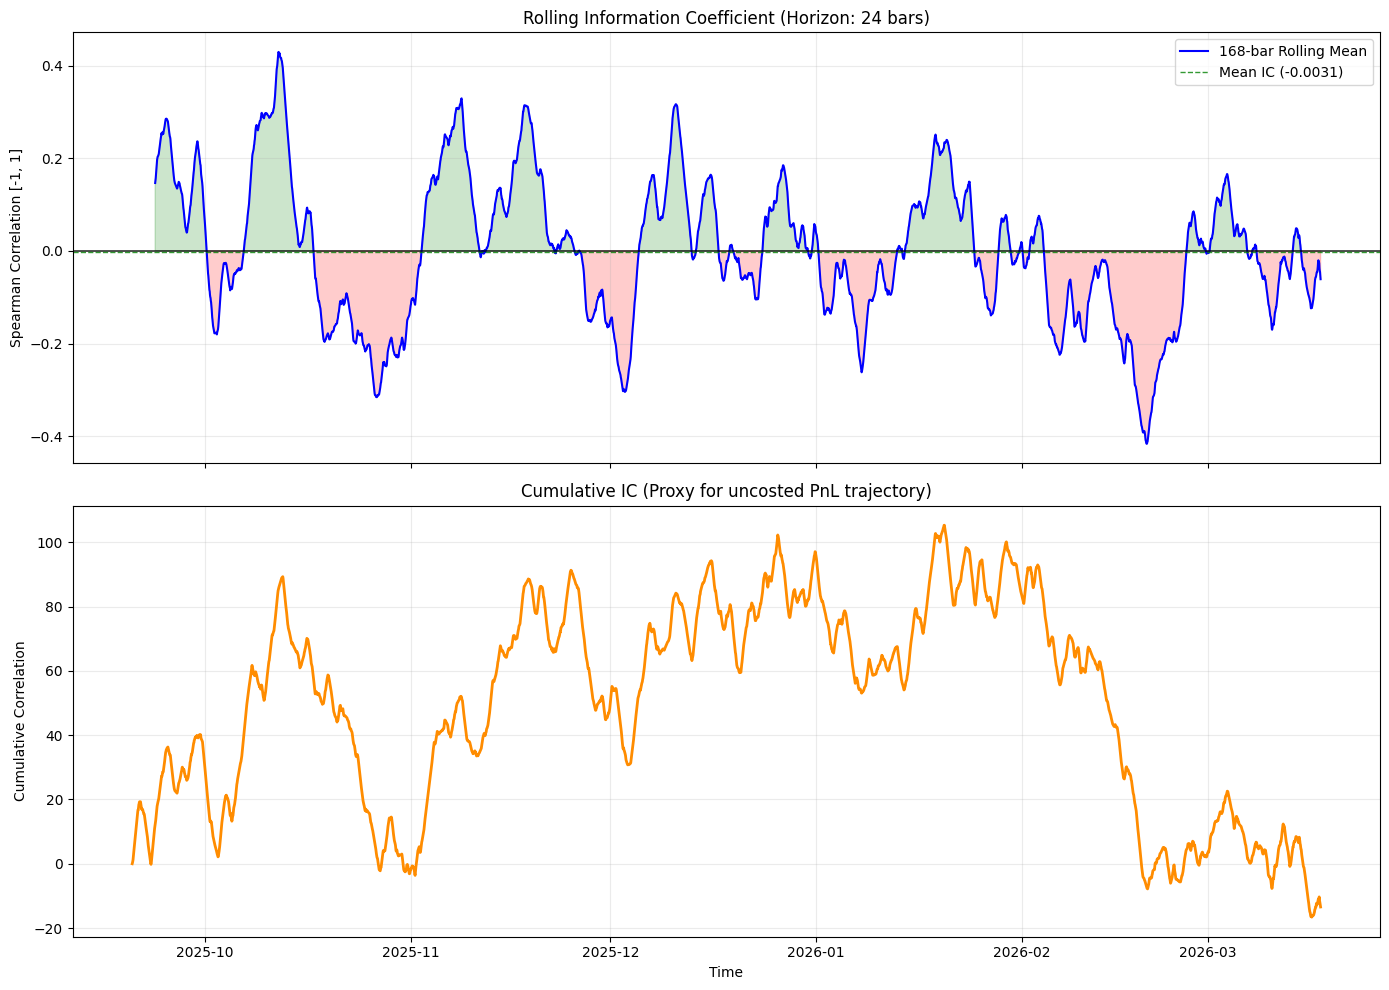

In [30]:
# -------------------------------------------------------------------
# 1. CALCULATE FORWARD RETURNS
# -------------------------------------------------------------------
# We need to define our evaluation horizon. 
# If our signal is built for a 3-day hold, evaluating 1-hour forward returns is mostly noise.
# Let's use a 24-hour (1-day) forward return for this example.
horizon_bars = 24 

# pct_change gives the backward return. We shift it negatively to make it the FORWARD return.
# At time 't', this cell contains the return from 't' to 't + horizon_bars'
fwd_returns = close_1h.pct_change(periods=horizon_bars).shift(-horizon_bars)

# -------------------------------------------------------------------
# 2. CALCULATE CROSS-SECTIONAL IC (Spearman Rank Correlation)
# -------------------------------------------------------------------
# We align our signal (combined_xsec) with the forward returns.
# Because combined_xsec is already shifted by 1 in earlier steps, there is no lookahead bias.

# Pandas corrwith(axis=1) computes the correlation row-by-row (timestamp-by-timestamp)
# We use 'spearman' to evaluate the rank-ordering power of the signal.
ic_series = combined_xsec.corrwith(fwd_returns, axis=1, method='spearman')

# Drop NaNs that occur at the end of the dataset due to the forward shift
ic_series = ic_series.dropna()

# -------------------------------------------------------------------
# 3. METRICS & SMOOTHING
# -------------------------------------------------------------------
# Raw IC is incredibly noisy. We smooth it with a rolling mean to see structural trends.
rolling_window = 24 * 7  # 7-day rolling window
rolling_ic = ic_series.rolling(window=rolling_window, min_periods=rolling_window//2).mean()

# Cumulative IC is a great proxy for un-levered, un-costed strategy performance.
cumulative_ic = ic_series.cumsum()

# Key Summary Statistics
mean_ic = ic_series.mean()
std_ic = ic_series.std()
ic_ir = mean_ic / std_ic if std_ic != 0 else 0  # Information Ratio of the IC
hit_rate = (ic_series > 0).mean() * 100         # % of periods with positive prediction

print("--- IC Summary Statistics ---")
print(f"Mean IC:      {mean_ic:.4f}")
print(f"IC Std Dev:   {std_ic:.4f}")
print(f"IC IR (Risk): {ic_ir:.4f}  (> 0.5 is good, > 1.0 is exceptional)")
print(f"Hit Rate:     {hit_rate:.2f}% (> 50% is required for edge)")

# -------------------------------------------------------------------
# 4. VISUALIZATION
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Plot 1: Rolling IC ---
axes[0].plot(rolling_ic.index, rolling_ic, color='blue', linewidth=1.5, label=f'{rolling_window}-bar Rolling Mean')
axes[0].axhline(0.0, color='black', linewidth=1.2, alpha=0.8)
axes[0].axhline(mean_ic, color='green', linestyle='--', linewidth=1, alpha=0.8, label=f'Mean IC ({mean_ic:.4f})')

# Fill between to highlight positive vs negative regimes
axes[0].fill_between(rolling_ic.index, rolling_ic, 0, where=(rolling_ic >= 0), color='green', alpha=0.2)
axes[0].fill_between(rolling_ic.index, rolling_ic, 0, where=(rolling_ic < 0), color='red', alpha=0.2)

axes[0].set_title(f'Rolling Information Coefficient (Horizon: {horizon_bars} bars)')
axes[0].set_ylabel('Spearman Correlation [-1, 1]')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.25)

# --- Plot 2: Cumulative IC ---
axes[1].plot(cumulative_ic.index, cumulative_ic, color='darkorange', linewidth=2)
axes[1].set_title('Cumulative IC (Proxy for uncosted PnL trajectory)')
axes[1].set_ylabel('Cumulative Correlation')
axes[1].set_xlabel('Time')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [12]:
# Optional cleanup: close DB handle when you are done with the notebook.
try:
    con.close()
    print('DuckDB connection closed.')
except Exception:
    pass

DuckDB connection closed.
